In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv("../Dataset/KTZH_00001202_00003680.csv")

# English translations
uber_map = {
    'Cybercrime (im engeren Sinne)': 'Cybercrime (narrow)',
    'digitalisierte Vermögenskriminalität': 'Digital Financial Crime',
    'Cyber-Sexualdelikte': 'Cyber Sexual Offences',
    'Cyber-Rufschädigung und unlauteres Verhalten': 'Cyber Defamation',
    'Darknet/Data Leaking': 'Darknet / Data Leaking',
}
unter_map = {
    'Phishing': 'Phishing',
    'Hacking': 'Hacking',
    'Malware': 'Malware',
    'DoS/DDoS': 'DoS/DDoS',
    'Cyberbetrug': 'Cyber Fraud',
    'Finanz- und Paketagenten': 'Financial & Package Agents',
    'Sextortion (money)': 'Sextortion',
    'Sexualdelikte': 'Sexual Offences',
    'Rufschädigung und unlauteres Verhalten': 'Defamation',
    'Diebstahl Kryptowährungen': 'Crypto Theft',
    'Illegaler Handel im Darknet': 'Illegal Darknet Trade',
    'Data leaking': 'Data Leaking',
}
df['category'] = df['CyberModus_Überkategorie'].map(uber_map)
df['subcategory'] = df['CyberModus_Unterkategorie'].map(unter_map)

df

,Ausgangsjahr,CyberModus_Überkategorie,CyberModus_Unterkategorie,Straftaten_total,Straftaten_vollendet,Straftaten_versucht,Einwohner,Häufigkeitszahl,category,subcategory
0,2017,Cybercrime (im engeren Sinne),Phishing,336,275,61,1487969,0.2,Cybercrime (narrow),Phishing
1,2017,Cybercrime (im engeren Sinne),Hacking,151,133,18,1487969,0.1,Cybercrime (narrow),Hacking
2,2017,Cybercrime (im engeren Sinne),Malware,77,70,7,1487969,0.1,Cybercrime (narrow),Malware
3,2017,Cybercrime (im engeren Sinne),DoS/DDoS,26,18,8,1487969,0.0,Cybercrime (narrow),DoS/DDoS
4,2017,digitalisierte Vermögenskriminalität,Cyberbetrug,1273,1132,141,1487969,0.9,Digital Financial Crime,Cyber Fraud
...,...,...,...,...,...,...,...,...,...,...
88,2024,digitalisierte Vermögenskriminalität,Diebstahl Kryptowährungen,27,27,0,1605508,0.0,Digital Financial Crime,Crypto Theft
89,2024,Cyber-Sexualdelikte,Sexualdelikte,649,639,10,1605508,0.4,Cyber Sexual Offences,Sexual Offences
90,2024,Cyber-Rufschädigung und unlauteres Verhalten,Rufschädigung und unlauteres Verhalten,74,71,3,1605508,0.0,Cyber Defamation,Defamation
91,2024,Darknet/Data Leaking,Illegaler Handel im Darknet,0,0,0,1605508,0.0,Darknet / Data Leaking,Illegal Darknet Trade


---
## Dataset Analysis & Key Findings

### Overview

In [53]:
# Dataset overview
print(f"Shape: {df.shape}")
print(f"\nYears covered: {sorted(df['Ausgangsjahr'].unique())}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nNumeric summary:")
df[['Straftaten_total','Straftaten_vollendet','Straftaten_versucht','Einwohner','Häufigkeitszahl']].describe().round(2)

Shape: (93, 10)

Years covered: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Missing values:
Ausgangsjahr                 0
CyberModus_Überkategorie     0
CyberModus_Unterkategorie    0
Straftaten_total             0
Straftaten_vollendet         0
Straftaten_versucht          0
Einwohner                    0
Häufigkeitszahl              0
category                     0
subcategory                  0
dtype: int64

Numeric summary:


,Straftaten_total,Straftaten_vollendet,Straftaten_versucht,Einwohner,Häufigkeitszahl
count,93.00,93.00,93.00,93.00,93.00
mean,579.17,534.24,44.94,1545967.32,0.37
std,1492.78,1409.81,94.38,35832.23,0.94
min,0.00,0.00,0.00,1487969.00,0.00
25%,17.00,15.00,1.00,1520968.00,0.00
50%,115.00,93.00,11.00,1553423.00,0.10
75%,410.00,331.00,31.00,1577088.00,0.30
max,10692.00,10213.00,479.00,1605508.00,6.70


### Finding 1 — Cybercrime is growing rapidly

Yearly totals and YoY growth:
 Ausgangsjahr  total  rate  yoy_growth_pct
         2017   2166   1.5             NaN
         2018   3580   2.5            65.3
         2019   4201   2.9            17.3
         2020   5673   3.7            35.0
         2021   6898   4.4            21.6
         2022   7465   4.7             8.2
         2023   9718   6.1            30.2
         2024  14162   8.8            45.7


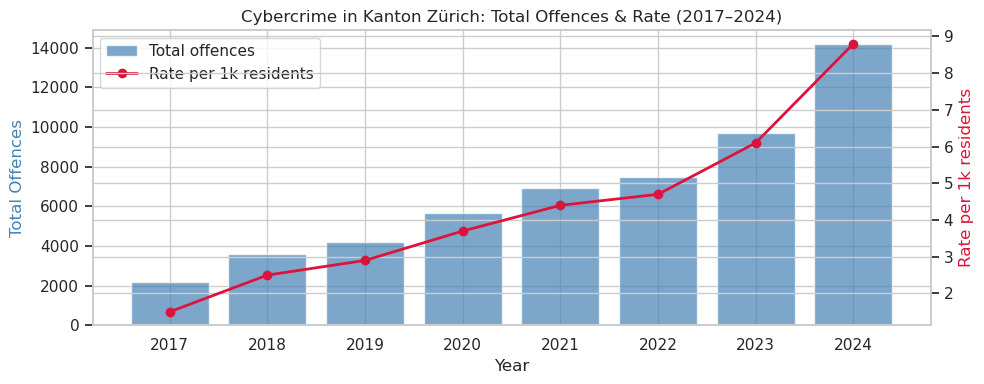

In [54]:
# Total crimes per year + YoY growth
yearly = df.groupby('Ausgangsjahr').agg(
    total=('Straftaten_total', 'sum'),
    rate=('Häufigkeitszahl', 'sum')
).reset_index()
yearly['yoy_growth_pct'] = yearly['total'].pct_change().mul(100).round(1)
print("Yearly totals and YoY growth:")
print(yearly.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(yearly['Ausgangsjahr'], yearly['total'], color='steelblue', alpha=0.7, label='Total offences')
ax2.plot(yearly['Ausgangsjahr'], yearly['rate'], color='crimson', marker='o', linewidth=2, label='Rate per 1k residents')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Offences', color='steelblue')
ax2.set_ylabel('Rate per 1k residents', color='crimson')
ax1.set_title('Cybercrime in Kanton Zürich: Total Offences & Rate (2017–2024)')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

### Finding 2 — Category Breakdown

Offences by top-level category:
                         total     %
category                            
Digital Financial Crime  42368  78.7
Cybercrime (narrow)       6861  12.7
Cyber Sexual Offences     3939   7.3
Cyber Defamation           694   1.3
Darknet / Data Leaking       1   0.0


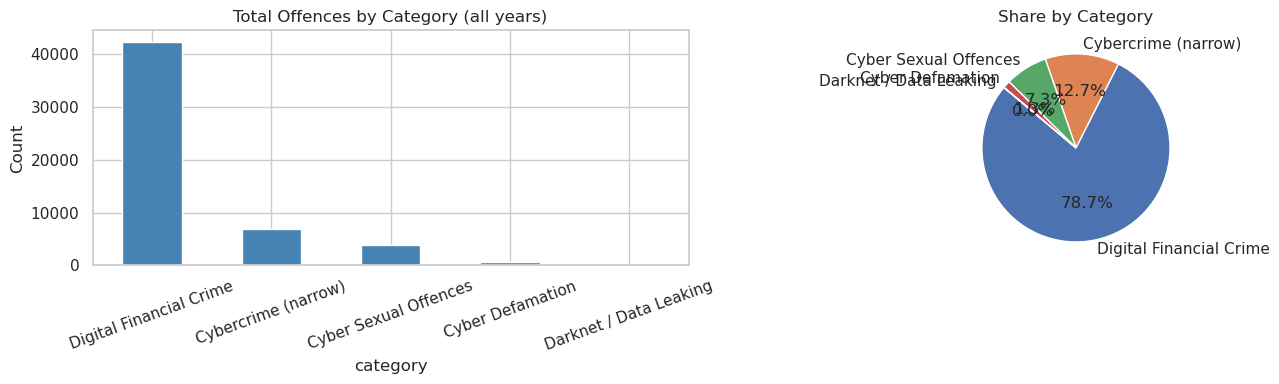

In [56]:
# Total offences by category (all years)
uber_total = df.groupby('category')['Straftaten_total'].sum().sort_values(ascending=False)
uber_pct = (uber_total / uber_total.sum() * 100).round(1)
print("Offences by top-level category:")
print(pd.DataFrame({'total': uber_total, '%': uber_pct}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
uber_total.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Offences by Category (all years)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(uber_total, labels=uber_total.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Share by Category')

plt.tight_layout()
plt.show()

Offences by subcategory:
subcategory
Cyber Fraud                   36126
Financial & Package Agents     4311
Sexual Offences                3939
Phishing                       3795
Hacking                        2077
Sextortion                     1790
Malware                         880
Defamation                      694
Crypto Theft                    141
DoS/DDoS                        109
Data Leaking                      1
Illegal Darknet Trade             0


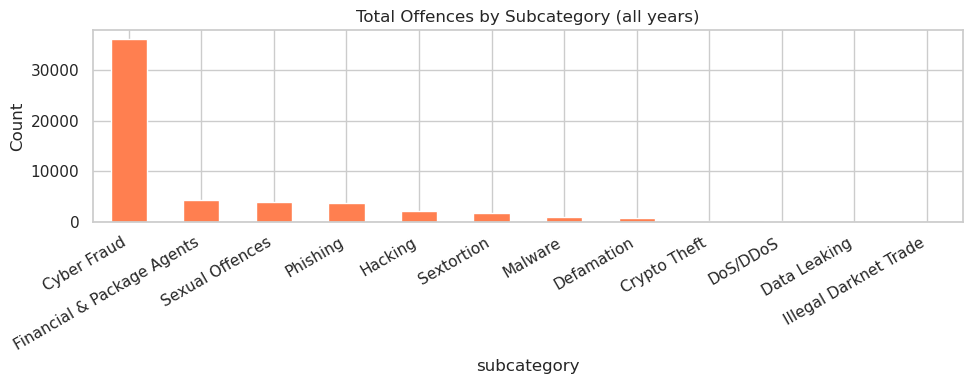

In [57]:
# Total offences by subcategory
unter_total = df.groupby('subcategory')['Straftaten_total'].sum().sort_values(ascending=False)
print("Offences by subcategory:")
print(unter_total.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
unter_total.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Total Offences by Subcategory (all years)')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Finding 3 — Trends by Category Over Time

category      Cyber Defamation  Cyber Sexual Offences  Cybercrime (narrow)  \
Ausgangsjahr                                                                 
2017                        76                    120                  590   
2018                        82                    148                  868   
2019                       115                    587                  428   
2020                        91                    587                  555   
2021                        94                    578                  815   
2022                        93                    697                  868   
2023                        69                    573                 1143   
2024                        74                    649                 1594   

category      Darknet / Data Leaking  Digital Financial Crime  
Ausgangsjahr                                                   
2017                               0                     1380  
2018                       

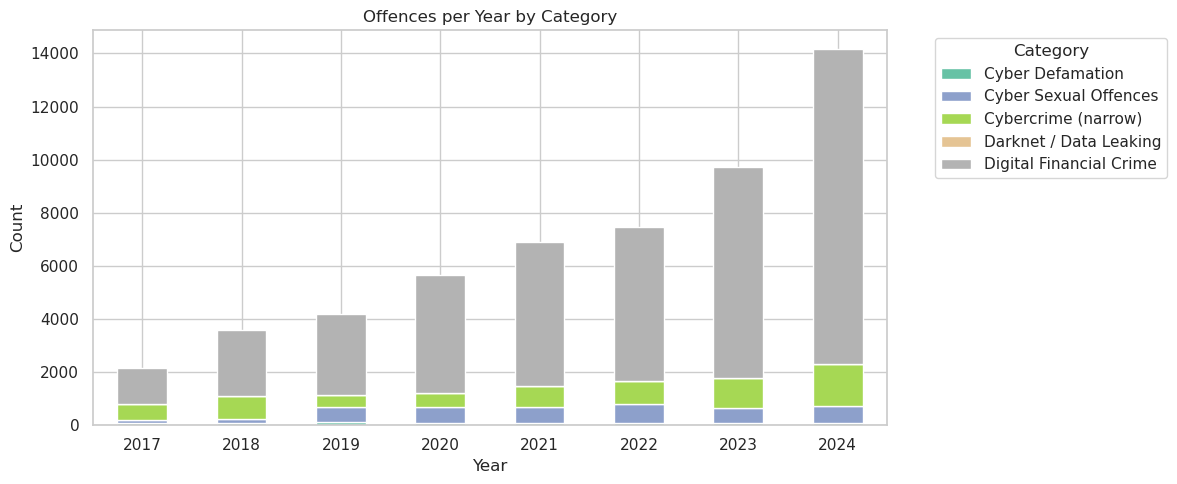

In [58]:
# Offences per year broken down by top-level category
cat_year = df.groupby(['Ausgangsjahr', 'category'])['Straftaten_total'].sum().unstack(fill_value=0)
print(cat_year)

cat_year.plot(kind='bar', figsize=(12, 5), colormap='Set2', stacked=True)
plt.title('Offences per Year by Category')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

subcategory   Crypto Theft  Cyber Fraud  Data Leaking  Defamation  DoS/DDoS  \
Ausgangsjahr                                                                  
2017                     0         1273             0          76        26   
2018                     0         2294             0          82        17   
2019                     4         2628             0         115         5   
2020                    12         3432             0          91        17   
2021                    34         4224             0          94        17   
2022                    42         4764             0          93         5   
2023                    22         6819             0          69        10   
2024                    27        10692             1          74        12   

subcategory   Financial & Package Agents  Hacking  Illegal Darknet Trade  \
Ausgangsjahr                                                               
2017                                  56      151        

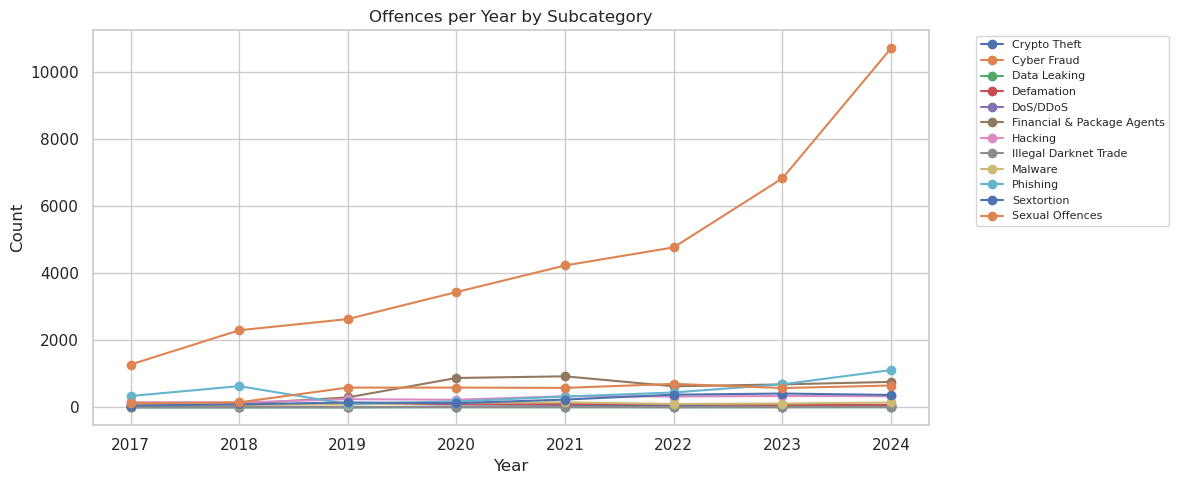

In [43]:
# Trend lines per subcategory over time
sub_year = df.groupby(['Ausgangsjahr', 'subcategory'])['Straftaten_total'].sum().unstack(fill_value=0)
print(sub_year)

fig, ax = plt.subplots(figsize=(12, 5))
for col in sub_year.columns:
    ax.plot(sub_year.index, sub_year[col], marker='o', label=col)
ax.set_title('Offences per Year by Subcategory')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Finding 4 — Completion Rate (Completed vs Attempted)

Avg completion rate by category (%):
category
Darknet / Data Leaking     100.0
Cyber Sexual Offences       97.6
Cyber Defamation            91.6
Cybercrime (narrow)         87.6
Digital Financial Crime     86.4

Avg completion rate by subcategory (%):
subcategory
Data Leaking                  100.0
Crypto Theft                   99.5
Sexual Offences                97.6
Hacking                        94.0
Financial & Package Agents     93.3
Phishing                       92.2
Defamation                     91.6
Cyber Fraud                    91.1
DoS/DDoS                       83.3
Malware                        81.0
Sextortion                     65.1
Illegal Darknet Trade           NaN


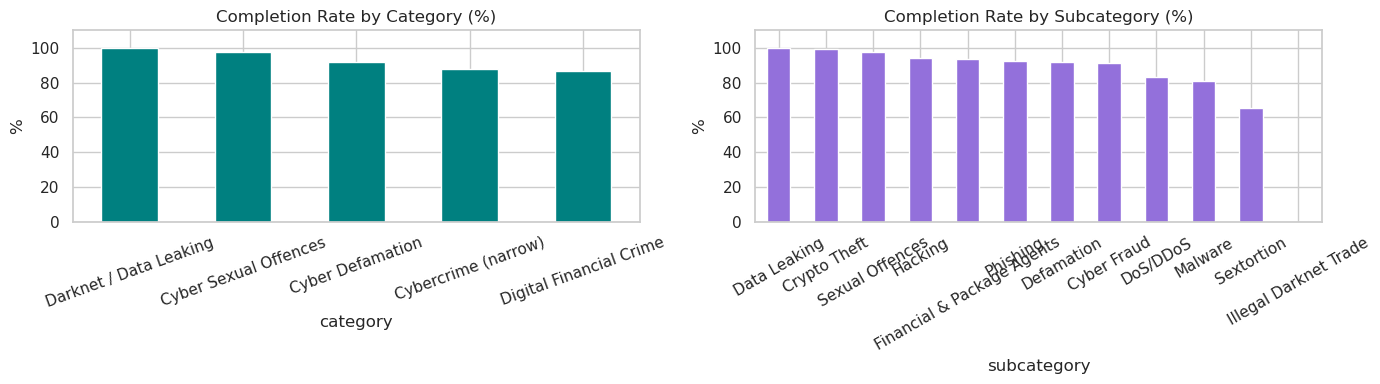

In [44]:
# Completion rate by category and subcategory
df2 = df.copy()
df2['completion_rate'] = df2['Straftaten_vollendet'] / df2['Straftaten_total'].replace(0, float('nan'))

comp_cat = df2.groupby('category')['completion_rate'].mean().sort_values(ascending=False).mul(100).round(1)
comp_sub = df2.groupby('subcategory')['completion_rate'].mean().sort_values(ascending=False).mul(100).round(1)

print("Avg completion rate by category (%):")
print(comp_cat.to_string())
print("\nAvg completion rate by subcategory (%):")
print(comp_sub.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
comp_cat.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Completion Rate by Category (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 110)

comp_sub.plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Completion Rate by Subcategory (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

### Finding 5 — Offence Rate per 1,000 Residents (Häufigkeitszahl)

Offence rate per 1k residents by subcategory and year:
subcategory   Crypto Theft  Cyber Fraud  Data Leaking  Defamation  DoS/DDoS  Financial & Package Agents  Hacking  Illegal Darknet Trade  Malware  Phishing  Sextortion  Sexual Offences
Ausgangsjahr                                                                                                                                                                           
2017                   0.0          0.9           0.0         0.1       0.0                         0.0      0.1                    0.0      0.1       0.2         0.0              0.1
2018                   0.0          1.5           0.0         0.1       0.0                         0.1      0.1                    0.0      0.1       0.4         0.1              0.1
2019                   0.0          1.7           0.0         0.1       0.0                         0.2      0.2                    0.0      0.1       0.1         0.1              0.4
2020                   0.

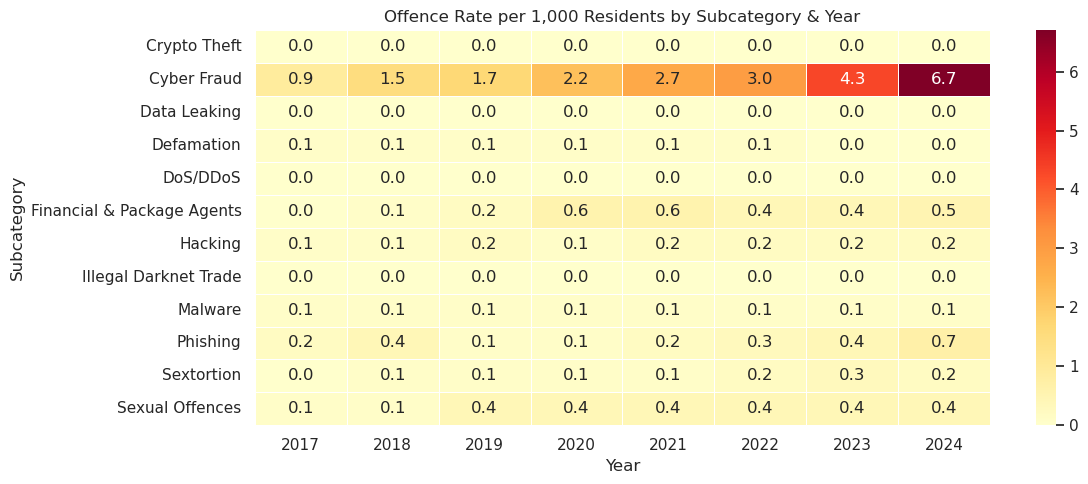

In [45]:
# Häufigkeitszahl (offence rate per 1k residents) by subcategory and year
rate_sub = df.groupby(['Ausgangsjahr', 'subcategory'])['Häufigkeitszahl'].sum().unstack(fill_value=0)
print("Offence rate per 1k residents by subcategory and year:")
print(rate_sub.round(2).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(rate_sub.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Offence Rate per 1,000 Residents by Subcategory & Year')
ax.set_xlabel('Year')
ax.set_ylabel('Subcategory')
plt.tight_layout()
plt.show()

### Finding 6 — Numeric Distributions & Correlations

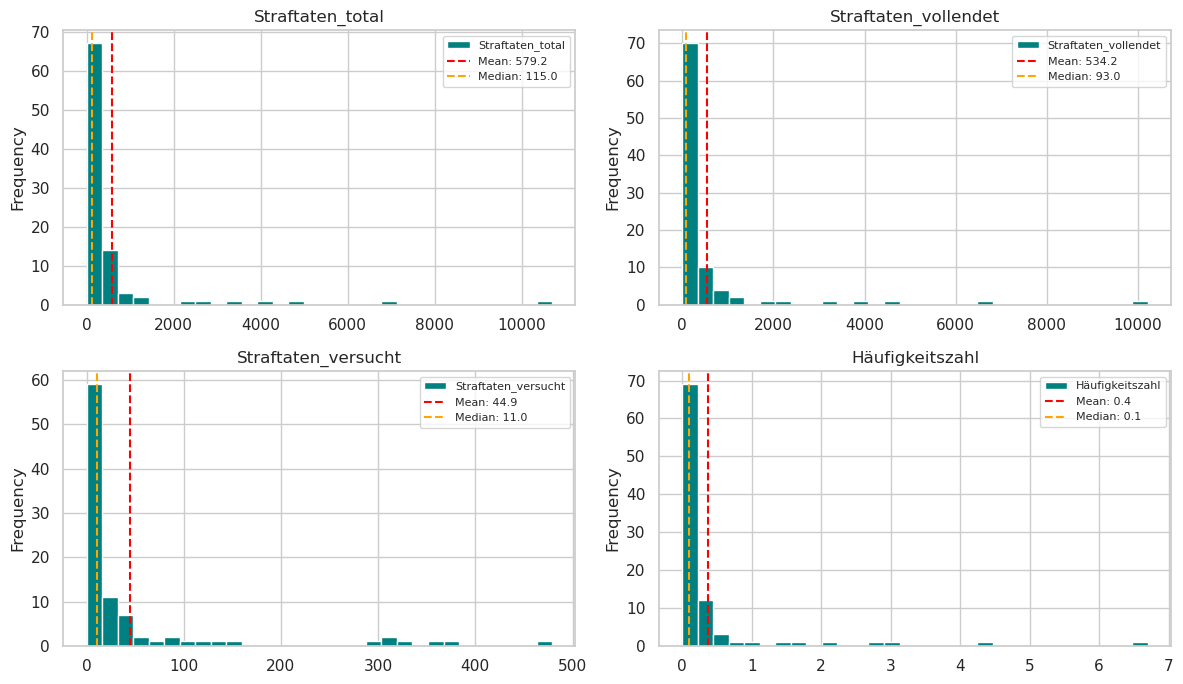

In [46]:
# Distributions of numeric columns
num_cols = ['Straftaten_total', 'Straftaten_vollendet', 'Straftaten_versucht', 'Häufigkeitszahl']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].plot(kind='hist', bins=30, ax=ax, color='teal', edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median: {df[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

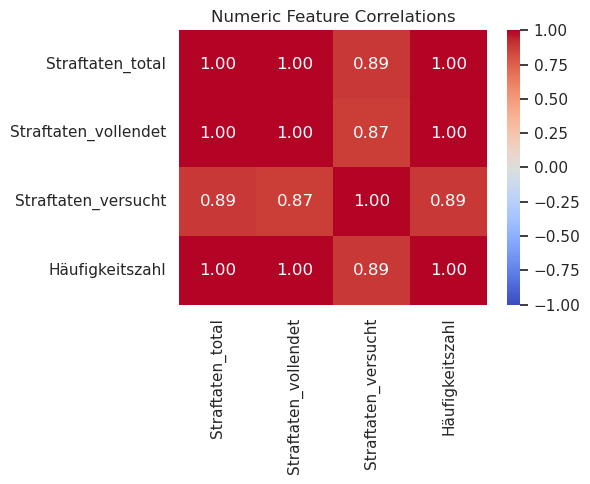

                            Completed  Attempted
subcategory                                     
Cyber Fraud                     33524       2602
Financial & Package Agents       4064        247
Sexual Offences                  3859         80
Phishing                         3524        271
Hacking                          1968        109
Sextortion                       1177        613
Malware                           709        171
Defamation                        633         61
Crypto Theft                      140          1
DoS/DDoS                           85         24
Data Leaking                        1          0
Illegal Darknet Trade               0          0


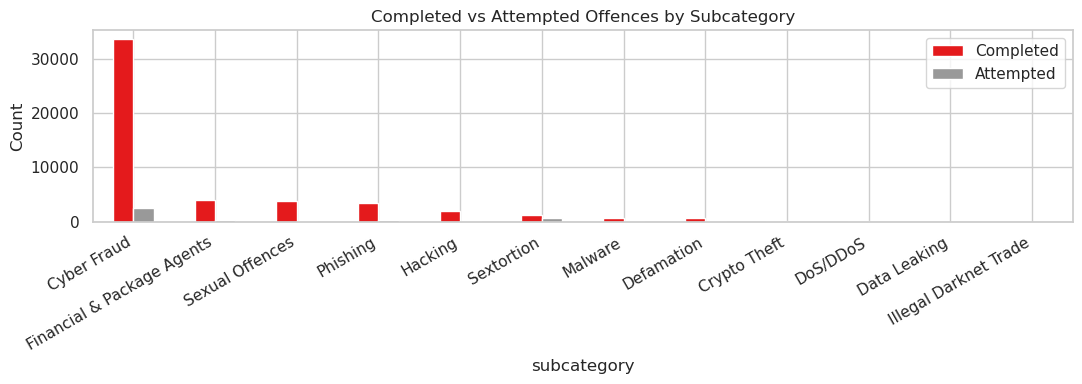

In [47]:
# Correlation heatmap
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

# Attempted vs completed offences by subcategory
sub_comp = df.groupby('subcategory')[['Straftaten_vollendet','Straftaten_versucht']].sum()
sub_comp.columns = ['Completed', 'Attempted']
sub_comp = sub_comp.sort_values('Completed', ascending=False)
print(sub_comp)

sub_comp.plot(kind='bar', figsize=(11, 4), colormap='Set1')
plt.title('Completed vs Attempted Offences by Subcategory')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()